In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18
import numpy as np
import matplotlib.pyplot as plt
import mat73
import scipy.signal as ss
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from scipy import signal

'C:\\Users\\Benedetta\\Desktop\\Criticality in barrel cortex\\Codes\\Marianietal2026-PlosCompBio'

In [2]:
plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [168]:
#local_data_path = "C:/Users/Benedetta/Downloads/Barrel+Talamo/Barrel+Talamo/"

In [137]:
#import os
#os.chdir(local_data_path)

In [3]:
cd D:

D:\


In [4]:
cd new_data_thalamus/

D:\new_data_thalamus


In [5]:
import os
import numpy as np
import scipy.signal as ss
from scipy import signal
import mat73


# =========================
# Filtering
# =========================

def bandpass_lfp(data, fs, low=0.1, high=50, order=2):
    nyq = 0.5 * fs
    b, a = ss.butter(order, [low/nyq, high/nyq], btype="bandpass")
    return ss.filtfilt(b, a, data, axis=1)


def notch_filter(data, fs, f0=100.0, Q=30.0):
    b, a = ss.iirnotch(f0, Q, fs)
    return ss.filtfilt(b, a, data, axis=1)


def filter_pipeline(data, fs, thalamus=True):
    sig = bandpass_lfp(data, fs)
    if thalamus:
        sig = notch_filter(sig, fs)
    return sig


# =========================
# Epoching
# =========================

def epoch_signal(sig, indexes, fs, pre_sec=1, post_sec=5, nchan=30):
    pre  = int(fs * pre_sec)
    post = int(fs * post_sec)

    n_samples = sig.shape[1]
    trials = []

    for r in range(1, len(indexes) - 1):
        start = indexes[r] - pre
        stop  = indexes[r] + post

        # boundary check
        if start < 0 or stop >= n_samples:
            continue

        trial = sig[:nchan, start:stop]
        trials.append(trial)

    return np.array(trials)


# =========================
# Main processing
# =========================

def process_file(filepath, thalamus=True, fs=25000,pre_sec=1, post_sec=10):
    
    print(os.getcwd(), filepath)
    
    data_dict = mat73.loadmat(filepath)
    data = data_dict['amplifier_data']
    
    stim = data_dict['adc_data'][0] if thalamus else data_dict['adc_data']


    indexes = (np.where(stim > 1.5)[0])[
        np.where(np.diff(np.where(stim > 1.5)[0]) > 1)
    ]
    indexes = np.array(
        indexes.tolist() + 
        [int(indexes[-1] + np.diff(indexes)[-1])]
    ) - 125
    # --------------------------------------------------

    sig = filter_pipeline(data, fs, thalamus=thalamus)
    del data
    nchan = 30 if thalamus else 27
    lfpTrials = epoch_signal(sig, indexes, fs, nchan=nchan, pre_sec=pre_sec, post_sec=post_sec)

    if thalamus:
        lfpTrials = np.delete(lfpTrials, [12,13,14,15,16,17,18,19], axis=1)

    return lfpTrials


# =========================
# Loop rats
# =========================

def run_analysis(nrat=0, start=0, thalamus=True, T = 10 ):

    files = os.listdir()[start:]
    #print(os.listdir())
    file = files[nrat]

    if file == "Figs":
        return None

    lfpTrials = process_file(file, thalamus=thalamus, pre_sec=1, post_sec=T)

    return lfpTrials


rat =int(input('insert rat'))
start =int(input('insert start'))
T = int(input("T"))
lfpTrials = run_analysis(nrat=rat, start=start, thalamus=True, T = T)
    

insert rat 2
insert start 0
T 5


D:\new_data_thalamus Piezo_220211_114822.mat


In [9]:
downsampled = ss.decimate(lfpTrials,10,axis = 2)
print(downsampled.shape)
del lfpTrials

(58, 22, 15000)


In [11]:
lfpTrials = downsampled

In [13]:

import emd
from scipy import signal

import emd
from scipy import signal

fac = 10
final = []
sample_rate=int(25000/fac)
post = 3
ii = 30
for ch in [15,16,17,18,19,]:
    for tr in range(lfpTrials.shape[0]):
        x = downsampled[tr,ch,sample_rate:sample_rate*post]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        #ii = 25 ##attenzione
        imf = emd.sift.mask_sift(x, max_imfs=7, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final.append(spec[:,:6])
        #print(spec.shape)
final = np.asarray(final)
fac = 10
final_r = []
sample_rate=int(25000/fac)
start_rest, end_rest = 3,T +1 

for ch in [15,16,17,18,19,]:
    for tr in range(lfpTrials.shape[0]):
        x = downsampled[tr,ch,sample_rate*start_rest:sample_rate*end_rest] 
        
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
    
        imf = emd.sift.mask_sift(x, max_imfs=7, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final_r.append(spec[:,:6])
        
final_r = np.asarray(final_r)

import emd
from scipy import signal
fac = 10
final_th = []
sample_rate=int(25000/fac)


for ch in [5,6,7,8,9,10]:
    for tr in range(lfpTrials.shape[0]):
        x = downsampled[tr,ch,sample_rate:sample_rate*post]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        #ii = 30 
        imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final_th.append(spec[:,:6])
final_th = np.asarray(final_th)
import emd
from scipy import signal


fac = 10
final_th_r = []
sample_rate=int(25000/fac)

for ch in [5,6,7,8,9,10]:
    for tr in range(lfpTrials.shape[0]):
       
        x = downsampled[tr,ch,sample_rate*start_rest:sample_rate*end_rest]
        t = np.arange(0,len(x),1)/sample_rate
        num = int(len(x)/sample_rate)
        #ii = 30 
        imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
        freq_range = (0, 45, 64)
        hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
        final_th_r.append(spec[:,:6])
final_th_r = np.asarray(final_th_r)


In [15]:
T -2, downsampled.shape[2]/2500


#[5,6,7,8,9,10]

(3, 6.0)

In [19]:
lfpTrials.shape

(28, 22, 27500)

In [36]:
rat

1

In [125]:
rat

1

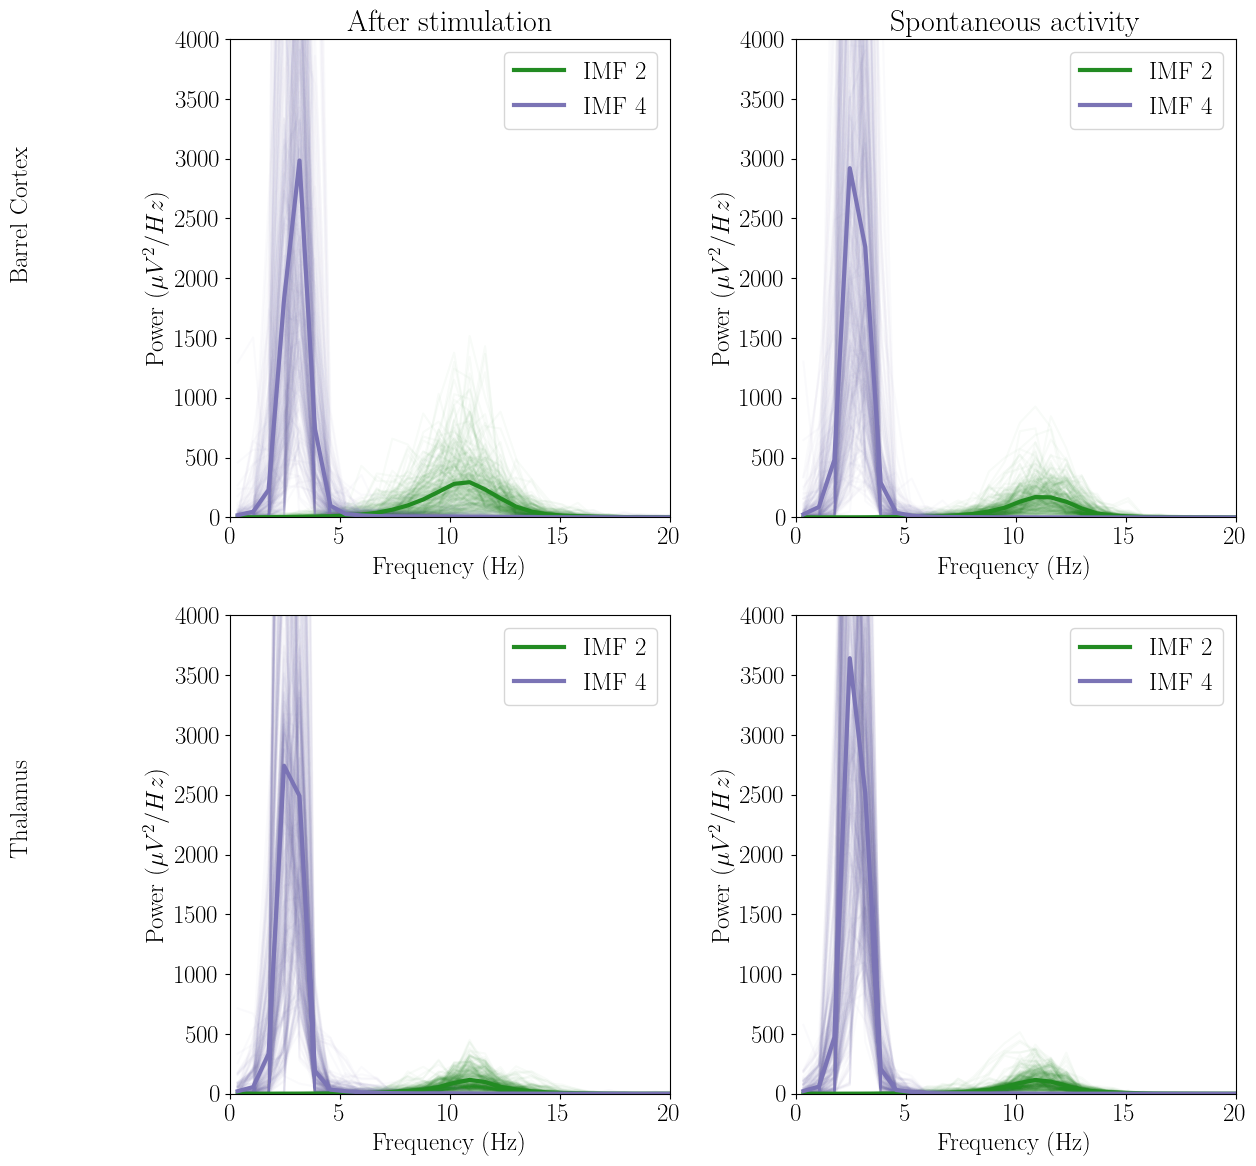

In [24]:
import emd
import warnings 
warnings.filterwarnings("ignore")
from matplotlib import cm

fig,ax = plt.subplots(2,2,figsize = (13,12))

ff = np.mean(final[:,:],0)

ax[0,0].plot(hht_f,final[:,:,1].T, color ='forestgreen', alpha = 0.03, );
ax[0,0].plot(hht_f,final[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.03, );
ax[0,0].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2")#label = "Hilbert-Huang Transform")
ax[0,0].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")#label = "Hilbert-Huang Transform")

ax[0,0].set_xlim(0, 20)
ax[0,0].legend()
ax[0,0].set_xlabel('Frequency (Hz)');
ax[0,0].set_ylabel(f'Power ($\mu V^2/Hz$)');

   
ax[0,0].set_ylim(0,4000)


ff = np.mean(final_r[:,:],0)

ax[0,1].plot(hht_f,final_r[:,:,1].T, color ='forestgreen', alpha = 0.03, );
ax[0,1].plot(hht_f,final_r[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.03, );
ax[0,1].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2")#label = "Hilbert-Huang Transform")
ax[0,1].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")#label = "Hilbert-Huang Transform"

ax[0,1].set_xlim(0, 20)
ax[0,1].legend()
ax[0,1].set_xlabel('Frequency (Hz)');
ax[0,1].set_ylabel(f'Power ($\mu V^2/Hz$)');
#ax[0,1].set_yscale('log')
ax[0,1].set_ylim(0,4000)
ax[0,0].set_title('After stimulation')
ax[0,1].set_title('Spontaneous activity')



ff = np.mean(final_th[:,:],0)

ax[1,0].plot(hht_f,final_th[:,:,1].T, color ='forestgreen', alpha = 0.03, );
ax[1,0].plot(hht_f,final_th[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.03, );
ax[1,0].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2")#label = "Hilbert-Huang Transform")
ax[1,0].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")#label = "Hilbert-Huang Transform")

ax[1,0].set_xlim(0, 50)
ax[1,0].legend()
ax[1,0].set_xlabel('Frequency (Hz)');
ax[1,0].set_ylabel(f'Power ($\mu V^2/Hz$)');
#ax[1,0].set_yscale('log')
ax[1,0].set_ylim(0,4000)
ax[1,0].set_xlim(0,20)


ff = np.mean(final_th_r[:,:],0)

ax[1,1].plot(hht_f,final_th_r[:,:,1].T, color ='forestgreen', alpha = 0.03, );
ax[1,1].plot(hht_f,final_th_r[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.03, );
ax[1,1].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2")#label = "Hilbert-Huang Transform")
ax[1,1].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")#label = "Hilbert-Huang Transform")

ax[1,1].legend()
ax[1,1].set_xlabel('Frequency (Hz)');
ax[1,1].set_ylabel(f'Power ($\mu V^2/Hz$)');
#plt.yscale('log')
ax[1,1].set_ylim(0,4000)
ax[1,1].set_xlim(0,20)


ax[0,0].text(-10,2000,'Barrel Cortex',rotation = 90)
ax[1,0].text(-10,2000,'Thalamus',rotation = 90)
annotate = False
if annotate:
    ax[0,0].annotate('\\textbf{(a)}', size = 20,
                     xy=(1, 1), xycoords='axes fraction',
                     xytext=(0.82,0.05), textcoords='axes fraction')
    
    ax[0,1].annotate('\\textbf{(b)}', size = 20,
                     xy=(1, 1), xycoords='axes fraction',
                     xytext=(0.82,0.05), textcoords='axes fraction')
    ax[1,0].annotate('\\textbf{(c)}', size = 20,
                     xy=(1, 1), xycoords='axes fraction',
                     xytext=(0.82,0.05), textcoords='axes fraction')
    ax[1,1].annotate('\\textbf{(d)}', size = 20,
                     xy=(1, 1), xycoords='axes fraction',
                     xytext=(0.82,0.05), textcoords='axes fraction')

plt.tight_layout();

## Pac plot

In [26]:
sample_rate=int(25000/fac)
import emd
nTrials = downsampled.shape[0]
nTrials
aa = []
aa1 = []
aa1_random =[]
channels = np.array([20,21,22,23,24,25,26,28,29])-8
for ch in channels:
    for tr in range(nTrials):
        tr_random = np.random.randint(0,nTrials)
        if (tr_random==tr):
            tr_random = np.random.randint(0,nTrials)
            print(tr_random==tr)

        
        x = downsampled[tr,ch,2500*3:]

        #ii = 25
        imf = emd.sift.mask_sift(x, max_imfs=6, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')

        #IP_, IF_, IA_ = emd.spectra.frequency_transform(imf[0][:,3] + imf[0][:,4], sample_rate, 'nht')
        ref1 = 3
        ref2 = 1
        ia_by_phase2, ia_by_phase_var2, phase_bins2 = emd.cycles.bin_by_phase(IP[:,ref1], IA[:, ref2], variance_metric ='std')
        phase_bins2 = phase_bins2[~np.isnan(ia_by_phase2)]
        ia_by_phase_var2 = ia_by_phase_var2[~np.isnan(ia_by_phase2)]
        ia_by_phase2 = ia_by_phase2[~np.isnan(ia_by_phase2)]
        aa.append((ia_by_phase2-np.mean(ia_by_phase2))/np.std(ia_by_phase2))
        aa1.append(ia_by_phase2)

        if phase_bins2.shape[0] ==22:
            print(tr, ch)
        
        #print(phase_bins2.shape)
        
        x = downsampled[tr_random,ch,2500*3:]

        #ii = 25
        imf = emd.sift.mask_sift(x, max_imfs=6, mask_freqs= ii/sample_rate, ret_mask_freq=True)
        IP_random, IF_random, IA_random = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')

        #IP_, IF_, IA_ = emd.spectra.frequency_transform(imf[0][:,3] + imf[0][:,4], sample_rate, 'nht')
        
    
        ref1 = 3
        ref2 = 1
  
        ia_by_phase2, ia_by_phase_var2, phase_bins2 = emd.cycles.bin_by_phase(IP_random[:,ref1], IA[:, ref2], variance_metric ='std')
        phase_bins2 = phase_bins2[~np.isnan(ia_by_phase2)]
       # print(phase_bins2.shape)
        if phase_bins2.shape[0] ==22:
            print(tr_random, ch)
        
        ia_by_phase_var2 = ia_by_phase_var2[~np.isnan(ia_by_phase2)]
        ia_by_phase2 = ia_by_phase2[~np.isnan(ia_by_phase2)]
        #aa.append((ia_by_phase2-np.mean(ia_by_phase2))/np.std(ia_by_phase2))
        aa1_random.append(ia_by_phase2)
        

False
False
False
False
False
False
False
False
False


In [27]:
np.mean(aa1,0).shape

(23,)

23
4 2
check : True
5 2
check : True
number of channels : 4
maxtor


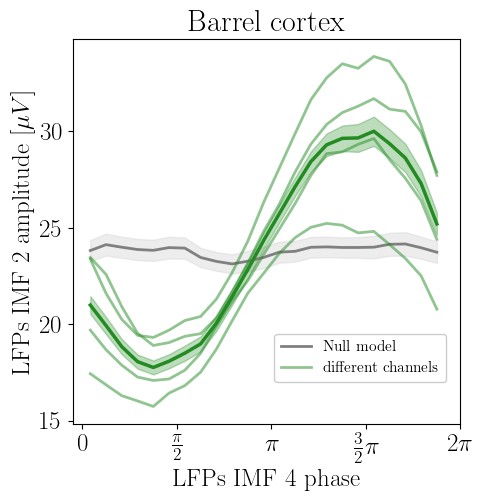

In [35]:
import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
path_figures = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures'
path_pac = path_figures + '/pac'

fig, ax = plt.subplots(1,1,figsize =(5,5))


#ax[0].set_title('Barrel (post stim)', fontsize = 18)
ax.set_title('Barrel cortex ',fontsize = 20)

num = 2
numero = 3
nTrials = downsampled.shape[0]



meanrandom = np.mean(aa1_random[nTrials*num:-nTrials*numero],0)
ax.fill_between(phase_bins2,meanrandom - np.std(aa1_random[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1_random[nTrials*num:-nTrials*numero])),meanrandom+ np.std(aa1_random[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1_random[nTrials*num:-nTrials*numero])),color='lightgray', alpha =.4)
ax.plot(phase_bins2, meanrandom, color ='gray', lw = 2., label ='Null model')
from scipy import ndimage


aasmean = np.mean(aa1[nTrials*num:-nTrials*numero],0)
print(len(aasmean))
o =0
for _,i in enumerate(range(num,int(len(aa1)/nTrials)-(numero+1))):
    ax.plot(phase_bins2, np.mean(aa1[i*nTrials:i*nTrials +nTrials],0),color ='forestgreen', lw = 2, alpha = .5, );#13

print(i,_)
print('check :', int((nTrials*9-nTrials*numero- nTrials*num)/nTrials) == (_+2))
i = i+1
ax.plot(phase_bins2, np.mean(aa1[i*nTrials:i*nTrials +nTrials],0),color ='forestgreen', lw = 2, alpha = .5,label='different channels' );#13


print(i,_)
print('check :', int((nTrials*9-nTrials*numero- nTrials*num)/nTrials) == (_+2))
print('number of channels :', _+2)

#ax[1,1].fill_between(p_mean,aas2mean - np.std(aas2)/np.sqrt(len(aas2)),aas2mean+ np.std(aas2)/np.sqrt(len(aas2)),color='r', alpha =.3)
ax.fill_between(phase_bins2,aasmean - np.std(aa1[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1[nTrials*num:-nTrials*numero])),aasmean+ np.std(aa1[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1[nTrials*num:-nTrials*numero])),color='forestgreen', alpha =.3)
ax.plot(phase_bins2, aasmean, color ='forestgreen', lw = 2.5)

ax.set_title('Barrel cortex')
ax.set_xlabel('LFPs IMF 4 phase')
ax.set_xticks([0,np.pi/2,np.pi,3/2*np.pi, 2*np.pi])
ax.set_xticklabels(["0",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3}{2}\pi$", r"$2\pi$"])
ax.set_ylabel(r'LFPs IMF 2 amplitude [$\mu V$]')
ax.legend(loc= (.52,.11), framealpha = 1, fontsize = 11);
label = 'pc' #maxtor

if start == 0: 
    label = 'maxtor'
elif start == 3:
    label = 'pc'
print(label)
#plt.savefig(path_pac + '/' + f"pac_{rat}_{label}.jpg", dpi=300, bbox_inches ='tight')

## Figure 2 plot

In [29]:
np.asarray(aa1).shape[0]/9

58.0

23
4 2
check : True
5 2
check : True


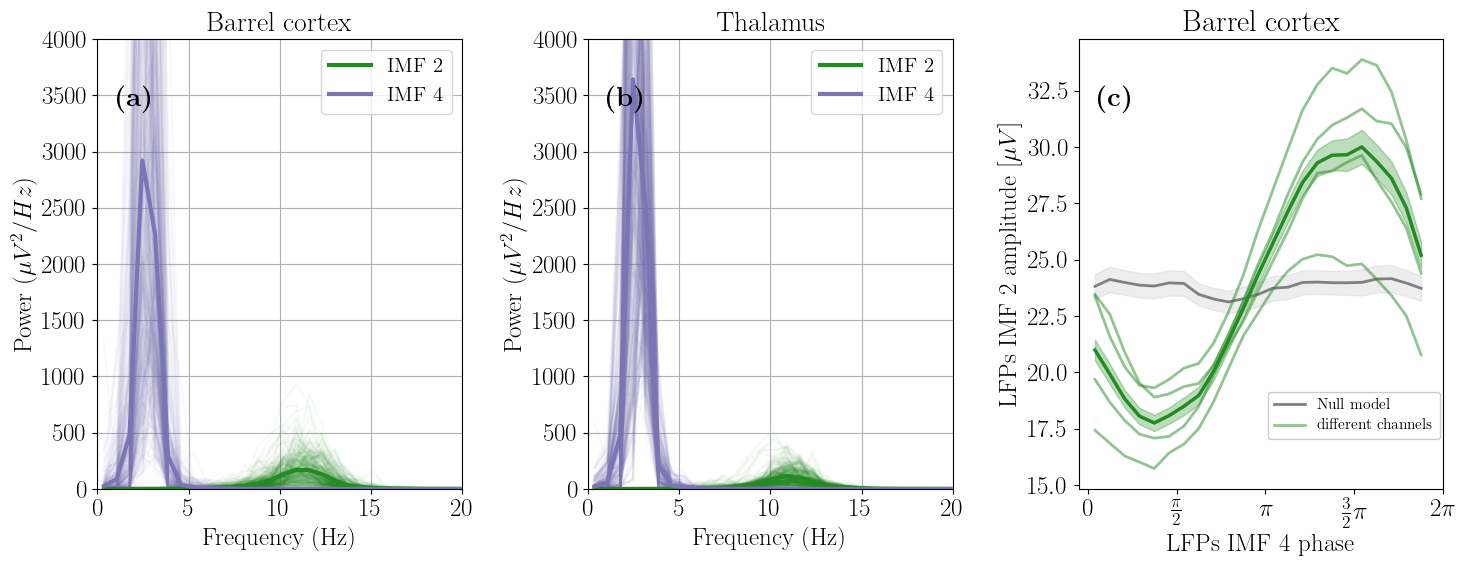

In [36]:
import emd
from matplotlib import cm
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,3,figsize = (15,6))

import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
fontprop = None

uptrial = 10
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
fontprop = None
#t = np.arange(0,int(25000/fac)*4,1)/int(25000/fac) - 1
#times = np.arange(0,25000*3,1)/25000-1




ff = np.mean(final_r[:,:],0)

ax[0].plot(hht_f,final_r[:,:,1].T, color ='forestgreen', alpha = 0.04, );
ax[0].plot(hht_f,final_r[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.04, );
ax[0].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2") ##label = "Hilbert-Huang Transform")
ax[0].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")#label = "Hilbert-Huang Transform")
ax[0].grid(True)
ax[0].set_xlim(0, 50)
ax[0].legend(fontsize = 15)
ax[0].set_xlabel('Frequency (Hz)');
ax[0].set_ylabel(f'Power ($\mu V^2/Hz$)');
#plt.yscale('log')
ax[0].set_ylim(0,4000)
ax[0].set_xlim(0,20)

ax[0].set_title('Barrel cortex', fontsize = 20)


## nrat = 3
ff = np.mean(final_th_r[:,:],0)

ax[1].plot(hht_f,final_th_r[:,:,1].T, color ='forestgreen', alpha = 0.04, );
ax[1].plot(hht_f,final_th_r[:,:,3].T, color =cm.get_cmap('Purples')(0.65), alpha = 0.04, );
ax[1].plot(hht_f, ff[:,1], lw = 3,color ='forestgreen',label = "IMF 2")#label = "Hilbert-Huang Transform")
ax[1].plot(hht_f, ff[:,3], lw = 3,color =cm.get_cmap('Purples')(0.65),label = "IMF 4")#label = "Hilbert-Huang Transform")
ax[1].grid(True)
ax[1].set_xlim(0, 50)
ax[1].legend(fontsize = 15)
ax[1].set_xlabel('Frequency (Hz)');
ax[1].set_ylabel(f'Power ($\mu V^2/Hz$)');
#plt.yscale('log')
ax[1].set_ylim(0,4000)
ax[1].set_xlim(0,20)
ax[1].set_title('Thalamus', fontsize = 20)

#ax[0].set_title('Barrel (post stim)', fontsize = 18)
ax[2].set_title('Barrel cortex ',fontsize = 20)

mean_interspike_time = 54
coef = 5
num = 2
numero = 3
nTrials=downsampled.shape[0]
meanrandom = np.mean(aa1_random[nTrials*num:-nTrials*numero],0)
ax[2].fill_between(phase_bins2,meanrandom - np.std(aa1_random[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1_random[nTrials*num:-nTrials*numero])),meanrandom+ np.std(aa1_random[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1_random[nTrials*num:-nTrials*numero])),color='lightgray', alpha =.4)
ax[2].plot(phase_bins2, meanrandom, color ='gray', lw = 2., label ='Null model')
from scipy import ndimage


aasmean = np.mean(aa1[nTrials*num:-nTrials*numero],0)
print(len(aasmean))
o =0
for _,i in enumerate(range(num,int(len(aa1)/nTrials)-(numero+1))):
    ax[2].plot(phase_bins2, np.mean(aa1[i*nTrials:i*nTrials +nTrials],0),color ='forestgreen', lw = 2, alpha = .5, );#13

print(i,_)
print('check :', int((nTrials*9-nTrials*numero- nTrials*num)/nTrials) == (_+2))
i = i+1
ax[2].plot(phase_bins2, np.mean(aa1[i*nTrials:i*nTrials +nTrials],0),color ='forestgreen', lw = 2, alpha = .5,label='different channels' );#13


print(i,_)
print('check :', int((nTrials*9-nTrials*numero- nTrials*num)/nTrials) == (_+2))


#ax[1,1].fill_between(p_mean,aas2mean - np.std(aas2)/np.sqrt(len(aas2)),aas2mean+ np.std(aas2)/np.sqrt(len(aas2)),color='r', alpha =.3)
ax[2].fill_between(phase_bins2,aasmean - np.std(aa1[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1[nTrials*num:-nTrials*numero])),aasmean+ np.std(aa1[nTrials*num:-nTrials*numero],0)/np.sqrt(len(aa1[nTrials*num:-nTrials*numero])),color='forestgreen', alpha =.3)
ax[2].plot(phase_bins2, aasmean, color ='forestgreen', lw = 2.5)

ax[2].set_title('Barrel cortex')
ax[2].set_xlabel('LFPs IMF 4 phase')
ax[2].set_xticks([0,np.pi/2,np.pi,3/2*np.pi, 2*np.pi])
ax[2].set_xticklabels(["0",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3}{2}\pi$", r"$2\pi$"])
ax[2].set_ylabel(r'LFPs IMF 2 amplitude [$\mu V$]')
ax[2].legend(loc= (.52,.11), framealpha = 1, fontsize = 11);
label = 'pc' #maxtor

#ax[2].legend(loc= (.01,.5), framealpha = 1, fontsize = 15)


ax[0].annotate('\\textbf{(a)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.85), textcoords='axes fraction')

ax[1].annotate('\\textbf{(b)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.85), textcoords='axes fraction')
ax[2].annotate('\\textbf{(c)}', size = 20,
                 xy=(1, 1), xycoords='axefraction',
                 xytext=(0.05,0.85), textcoords='axes fraction')

plt.tight_layout();

path = "C:/Users/Benedetta/Desktop/Criticality in barrel cortex"
#plt.savefig(path +"/Thalamus/Paper Figures/Figura_2_final.jpg", bbox_inches = 'tight', dpi = 300 )
#plt.savefig(path +"/Thalamus/Paper Figures/Figura_2_final.tif", bbox_inches = 'tight', dpi = 300 )


In [ ]:
fig, axes =plt.subplots(1,1)
ax =[0,0,axes]
meanrandom = np.mean(aa1_random[28*num:-28*numero],0)
#ax[2].fill_between(phase_bins2,meanrandom - np.std(aa1_random[28*num:-28*numero],0)/np.sqrt(len(aa1_random[28*num:-28*numero])),meanrandom+ np.std(aa1_random[28*num:-28*numero],0)/np.sqrt(len(aa1_random[28*num:-28*numero])),color='lightgray', alpha =.4)
#ax[2].plot(phase_bins2, meanrandom, color ='gray', lw = 2., label ='Null model')
from scipy import ndimage


aasmean = np.mean(aa1[28*num:-28*numero],0)
print(len(aasmean))
color= cm.Greens(np.linspace(0.1,1,10))
for _,i in enumerate(range(num,int(len(aa1)/28)-(numero+1))):
    ax[2].plot(phase_bins2, np.mean(aa1[i*28:i*28 +28],0),color =color[_], lw = 2, alpha = 1, );#13

print(i,_)
print('check :', int((280-28*numero- 28*num)/28) == (_+2))
i = i+1
ax[2].plot(phase_bins2, np.mean(aa1[i*28:i*28 +28],0),color =color[_+1], lw = 2, alpha = 1,label='different channels' );#13


color= cm.Reds(np.linspace(0.1,1,10))
for _,i in enumerate(range(num,int(len(aa1)/28)-(numero+1))):
    ax[2].plot(phase_bins2, np.mean(aa1_random[i*28:i*28 +28],0),color =color[_], lw = 2, alpha = 1, );#13

print(i,_)
print('check :', int((280-28*numero- 28*num)/28) == (_+2))
i = i+1
ax[2].plot(phase_bins2, np.mean(aa1_random[i*28:i*28 +28],0),color =color[_+1], lw = 2, alpha = 1,label='different channels' );#13


print(i,_)
print('check :', int((280-28*numero- 28*num)/28) == (_+2))


#ax[1,1].fill_between(p_mean,aas2mean - np.std(aas2)/np.sqrt(len(aas2)),aas2mean+ np.std(aas2)/np.sqrt(len(aas2)),color='r', alpha =.3)
#ax[2].fill_between(phase_bins2,aasmean - np.std(aa1[28*num:-28*numero],0)/np.sqrt(len(aa1[28*num:-28*numero])),aasmean+ np.std(aa1[28*num:-28*numero],0)/np.sqrt(len(aa1[28*num:-28*numero])),color='forestgreen', alpha =.3)
#ax[2].plot(phase_bins2, aasmean, color ='forestgreen', lw = 2.5)

ax[2].set_title('Barrel cortex')
ax[2].set_xlabel('LFPs IMF 4 phase')
ax[2].set_xticks([0,np.pi/2,np.pi,3/2*np.pi, 2*np.pi])
ax[2].set_xticklabels(["0",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3}{2}\pi$", r"$2\pi$"])
ax[2].set_ylabel(r'LFPs IMF 2 amplitude [$\mu V$]')
ax[2].legend(loc= (.62,.11), framealpha = 1, fontsize = 11);
label = 'pc' #maxtor